In [9]:
import os
import gc
import time
import json
import joblib
import threading
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score, 
    precision_recall_fscore_support, 
    ConfusionMatrixDisplay
)

INPUT_DIR = Path('/kaggle/input/datasets/b22dckh072/data-model5')

WORKING_DIR = Path('/kaggle/working')
OUTPUT_MODELS_DIR = WORKING_DIR / 'outputs' / 'models'
FIGURES_DIR = WORKING_DIR / 'outputs' / 'figures'

OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục đọc dữ liệu: {INPUT_DIR}")
print(f"Thư mục lưu mô hình: {OUTPUT_MODELS_DIR}")
print(f"Thư mục lưu biểu đồ: {FIGURES_DIR}")
LABEL_NAMES = ['negative', 'neutral', 'positive']

Thư mục đọc dữ liệu: /kaggle/input/datasets/b22dckh072/data-model5
Thư mục lưu mô hình: /kaggle/working/outputs/models
Thư mục lưu biểu đồ: /kaggle/working/outputs/figures


In [4]:
X_train = sparse.load_npz(INPUT_DIR / 'review_features_train.npz')
X_test  = sparse.load_npz(INPUT_DIR / 'review_features_test.npz')

y_train = np.load(INPUT_DIR / 'review_labels_train.npy')
y_test  = np.load(INPUT_DIR / 'review_labels_test.npy')

print(f"Kích thước X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"Kích thước X_test : {X_test.shape}  | y_test : {y_test.shape}")

Kích thước X_train: (16241239, 262144) | y_train: (16241239,)
Kích thước X_test : (3479704, 262144)  | y_test : (3479704,)


In [6]:
all_results = {}

def _print_timer(stop_event, model_name):
    """Thread in thời gian mỗi 30 giây"""
    t0 = time.time()
    while not stop_event.is_set():
        time.sleep(30)
        if stop_event.is_set():
            break
        elapsed = time.time() - t0
        mins    = int(elapsed // 60)
        secs    = int(elapsed % 60)
        print(f'[{model_name}] Đang train: {mins:02d}:{secs:02d}...', flush=True)

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):

    print(f'\n{"="*55}')
    print(f'Model: {model_name}')
    print(f'{"="*55}')

    # ── TRAIN ──────────────────────────────────────────────
    print(f'Training...')

    stop_event   = threading.Event()
    timer_thread = threading.Thread(
        target=_print_timer,
        args=(stop_event, model_name),
        daemon=True
    )
    timer_thread.start()

    t0         = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    stop_event.set()
    timer_thread.join()

    mins = int(train_time // 60)
    secs = int(train_time % 60)
    print(f' Train xong {mins:02d}:{secs:02d} ({train_time:.1f}s)')

    # ── PREDICT ────────────────────────────────────────────
    t1        = time.time()
    y_pred    = model.predict(X_test)
    pred_time = time.time() - t1
    print(f' Predict xong! {pred_time:.1f}s')

    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    print(f'\nKết quả:')
    print(f'   F1 Macro   : {f1_macro:.4f}')
    print(f'   F1 Weighted: {f1_weighted:.4f}')
    print(f'\n   Classification Report:')
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    cm   = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    save_path = FIGURES_DIR / f'step5_cm_{model_name.replace(" ","_").lower()}.png'
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

    result = {
        'model'         : model_name,
        'train_time_s'  : round(train_time, 1),
        'train_time_fmt': f'{mins:02d}:{secs:02d}',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
    }
    all_results[model_name] = result

    model_path = OUTPUT_MODELS_DIR / f'sentiment_{model_name.replace(" ","_").lower()}.joblib'
    joblib.dump(model, model_path)
    print(f'Lưu: {model_path.name}')

    return result


Logistic Regression


Model: Logistic Regression
Training...
[Logistic Regression] Đang train: 00:30...
[Logistic Regression] Đang train: 01:00...
[Logistic Regression] Đang train: 01:30...
[Logistic Regression] Đang train: 02:00...
[Logistic Regression] Đang train: 02:30...
[Logistic Regression] Đang train: 03:00...
[Logistic Regression] Đang train: 03:30...
[Logistic Regression] Đang train: 04:00...
[Logistic Regression] Đang train: 04:30...
[Logistic Regression] Đang train: 05:00...
[Logistic Regression] Đang train: 05:30...
[Logistic Regression] Đang train: 06:00...
[Logistic Regression] Đang train: 06:30...
[Logistic Regression] Đang train: 07:00...
[Logistic Regression] Đang train: 07:30...
[Logistic Regression] Đang train: 08:00...
[Logistic Regression] Đang train: 08:30...
[Logistic Regression] Đang train: 09:00...
[Logistic Regression] Đang train: 09:30...
[Logistic Regression] Đang train: 10:00...
[Logistic Regression] Đang train: 10:30...
[Logistic Regression] Đang train: 11:00...
[Logistic Regr

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


 Train xong 37:31 (2251.2s)
 Predict xong! 0.9s

Kết quả:
   F1 Macro   : 0.6766
   F1 Weighted: 0.8493

   Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.75      0.70    384718
     neutral       0.32      0.60      0.42    301193
    positive       0.98      0.86      0.92   2793793

    accuracy                           0.83   3479704
   macro avg       0.65      0.74      0.68   3479704
weighted avg       0.88      0.83      0.85   3479704



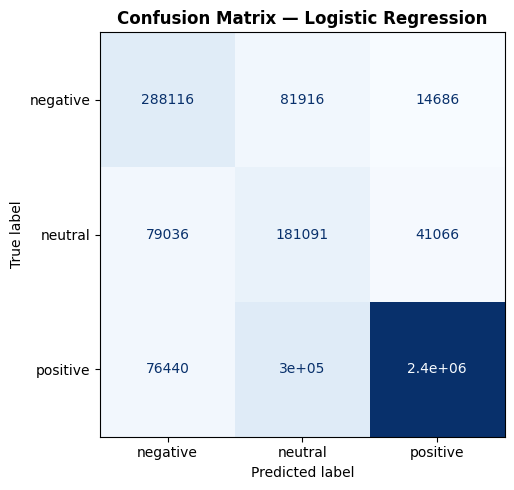

Lưu: sentiment_logistic_regression.joblib


In [7]:
lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 100,
    class_weight = 'balanced',
    solver       = 'saga',
    random_state = 42,
    n_jobs       = -1,
    verbose      = 0
)

lr_result = train_and_evaluate(
    lr_model, 'Logistic Regression',
    X_train, y_train, X_test, y_test
)


SGD Classifier


Model: SGD Classifier
Training...
[SGD Classifier] Đang train: 00:30...
[SGD Classifier] Đang train: 01:00...
 Train xong 01:13 (73.9s)
 Predict xong! 0.7s

Kết quả:
   F1 Macro   : 0.6869
   F1 Weighted: 0.8718

   Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.77      0.71    384718
     neutral       0.43      0.39      0.41    301193
    positive       0.95      0.94      0.94   2793793

    accuracy                           0.87   3479704
   macro avg       0.68      0.70      0.69   3479704
weighted avg       0.87      0.87      0.87   3479704



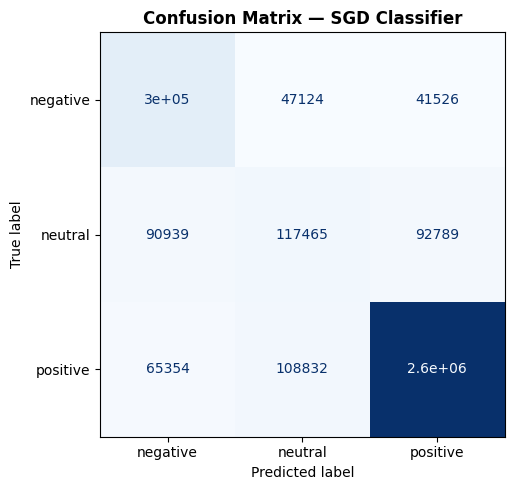

Lưu: sentiment_sgd_classifier.joblib


In [8]:
sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 1e-4,
    max_iter     = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

sgd_result = train_and_evaluate(
    sgd_model, 'SGD Classifier',
    X_train, y_train, X_test, y_test
)

Linear SVM

In [ ]:
svm_model = LinearSVC(
    C            = 1.0,
    max_iter     = 2000,
    class_weight = 'balanced',
    random_state = 42
)

svm_result = train_and_evaluate(
    svm_model, 'Linear SVM',
    X_train, y_train, X_test, y_test
)


Model: Linear SVM
Training...
[Linear SVM] Đang train: 00:30...
[Linear SVM] Đang train: 01:00...
[Linear SVM] Đang train: 01:30...
[Linear SVM] Đang train: 02:00...
[Linear SVM] Đang train: 02:30...
[Linear SVM] Đang train: 03:00...
[Linear SVM] Đang train: 03:30...
[Linear SVM] Đang train: 04:00...
[Linear SVM] Đang train: 04:30...
[Linear SVM] Đang train: 05:00...
[Linear SVM] Đang train: 05:30...
[Linear SVM] Đang train: 06:00...
[Linear SVM] Đang train: 06:30...
[Linear SVM] Đang train: 07:00...
[Linear SVM] Đang train: 07:30...
[Linear SVM] Đang train: 08:00...
[Linear SVM] Đang train: 08:30...
[Linear SVM] Đang train: 09:00...
[Linear SVM] Đang train: 09:30...
[Linear SVM] Đang train: 10:00...
[Linear SVM] Đang train: 10:30...
[Linear SVM] Đang train: 11:00...
[Linear SVM] Đang train: 11:30...
[Linear SVM] Đang train: 12:00...
[Linear SVM] Đang train: 12:30...
[Linear SVM] Đang train: 13:00...
[Linear SVM] Đang train: 13:30...
[Linear SVM] Đang train: 14:00...
[Linear SVM] Đang

Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 500,
    max_features = 'sqrt',
    max_depth    = 20,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

rf_result = train_and_evaluate(
    rf_model, 'Random Forest',
    X_train, y_train, X_test, y_test
)

In [ ]:
model_files = {
    'Logistic Regression' : 'sentiment_lr_model.joblib',
    'SGD Classifier'      : 'sentiment_sgd_model.joblib',
    'Linear SVM'          : 'sentiment_svm_model.joblib',
    'Random Forest'       : 'sentiment_rf_model.joblib',
}

print('Load lai models va tinh metrics...\n')

for model_name, fname in model_files.items():
    fpath = OUTPUT_MODELS_DIR / fname

    if not fpath.exists():
        print(f'Khong tim thay: {fname} -> bo qua')
        continue

    print(f'Loading {model_name}...')
    model = joblib.load(fpath)

    t0     = time.time()
    y_pred = model.predict(X_test)
    t1     = time.time()

    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    all_results[model_name] = {
        'model'         : model_name,
        'train_time_s'  : 0,
        'train_time_fmt': 'N/A',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
    }

    print(f'   F1-Macro={f1_macro:.4f} | F1-Weighted={f1_weighted:.4f} | {t1-t0:.1f}s\n')

with open(OUTPUT_MODELS_DIR / 'sentiment_traditional_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('='*55)
print('Da load du tat ca model:')
for name, r in all_results.items():
    print(f'   {name:<22}: F1-Macro={r["f1_macro"]} | F1-Weighted={r["f1_weighted"]}')

In [ ]:
df_results = pd.DataFrame(list(all_results.values()))
df_results = df_results.sort_values('f1_macro', ascending=False)

print('='*65)
print('BANG SO SANH KET QUA - TRADITIONAL ML')
print('='*65)
print(df_results[['model','f1_macro','f1_weighted',
                   'f1_negative','f1_neutral','f1_positive',
                   'train_time_s']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sanh Traditional ML Models - Sentiment Analysis',
              fontsize=13, fontweight='bold')

models = df_results['model'].tolist()
x      = range(len(models))

axes[0].bar([i - 0.2 for i in x], df_results['f1_macro'],
             width=0.4, label='F1 Macro', color='#3498db', alpha=0.85)
axes[0].bar([i + 0.2 for i in x], df_results['f1_weighted'],
             width=0.4, label='F1 Weighted', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('F1 Macro vs F1 Weighted', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.3, label='0.5 threshold')

for i, (macro, weighted) in enumerate(
    zip(df_results['f1_macro'], df_results['f1_weighted'])
):
    axes[0].text(i-0.2, macro+0.01, f'{macro:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, weighted+0.01, f'{weighted:.3f}', ha='center', fontsize=8)

width = 0.25
axes[1].bar([i - width for i in x], df_results['f1_negative'],
             width=width, label='Negative', color='#e74c3c', alpha=0.85)
axes[1].bar([i for i in x], df_results['f1_neutral'],
             width=width, label='Neutral', color='#f39c12', alpha=0.85)
axes[1].bar([i + width for i in x], df_results['f1_positive'],
             width=width, label='Positive', color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('F1 theo tung class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_traditional_ml_comparison.png',
             dpi=130, bbox_inches='tight')
plt.show()

best = df_results.iloc[0]
print(f'\nModel tot nhat: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')

with open(OUTPUT_MODELS_DIR / 'sentiment_traditional_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\n Lưu : sentiment_traditional_results.json')

In [ ]:
best_model_name = df_results.iloc[0]['model']
best_model_path = OUTPUT_MODELS_DIR / f'sentiment_{best_model_name.replace(" ","_").lower()}.joblib'
best_model      = joblib.load(best_model_path)

y_pred_best = best_model.predict(X_test)

cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Error Analysis - {best_model_name}',
              fontsize=13, fontweight='bold')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=LABEL_NAMES
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False,
           values_format='.2%')
axes[0].set_title('Confusion Matrix (Normalized)', fontweight='bold')

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average=None
)

x    = range(len(LABEL_NAMES))
axes[1].bar([i-0.25 for i in x], precision, width=0.25,
             label='Precision', color='#3498db', alpha=0.85)
axes[1].bar([i for i in x],      recall,    width=0.25,
             label='Recall',    color='#e74c3c', alpha=0.85)
axes[1].bar([i+0.25 for i in x], f1,       width=0.25,
             label='F1',        color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(LABEL_NAMES)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Precision / Recall / F1 theo Class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_error_analysis.png',
             dpi=130, bbox_inches='tight')
plt.show()

print('\nNhan xet Error Analysis:')
for i, (name, p, r, f) in enumerate(
    zip(LABEL_NAMES, precision, recall, f1)
):
    print(f'   {name:10}: Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}')

worst_class = LABEL_NAMES[f1.argmin()]
print(f'\nClass kem nhat: {worst_class} (F1={f1.min():.3f})')

In [ ]:
print('='*65)
print('TONG KET PHAN A - TRADITIONAL ML')
print('='*65)

print('\nBang so sanh cuoi:')
print(f'{"Model":<22} {"F1-Macro":>10} {"F1-Weighted":>12} {"Time(s)":>10}')
print('-'*58)
for _, row in df_results.iterrows():
    print(f'{row["model"]:<22} {row["f1_macro"]:>10.4f} '
          f'{row["f1_weighted"]:>12.4f} {row["train_time_s"]:>10.1f}')

best = df_results.iloc[0]
print(f'\nBest model: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')

print('\nFiles da luu:')
for f in sorted(OUTPUT_MODELS_DIR.glob('sentiment_*.joblib')):
    sz = f.stat().st_size / (1024**2)
    print(f'   {f.name:<45} {sz:.1f} MB')
print(f'   sentiment_traditional_results.json')

print('\nNhan xet chung:')
print('   -> Linear models (LR, SVM, SGD) thuong tot hon RF voi text')
print('   -> class_weight=balanced giup cai thien F1 neutral & negative')
print('   -> neutral la class kho nhat vi nam giua positive va negative')